#
 Inquilinos — RETOS (EDA + Modelado + Informe en el mismo Colab)




In [ ]:
#RETO 0.0 — Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
plt.rcParams.update({"figure.autolayout": True})


In [ ]:
inquilinos = pd.read_csv("/content/ds_inquilinos.csv")


In [ ]:
#RETO 1.2 — Vista rápida
inquilinos.head(10)


,id_inquilino,horario,ritmo,animacion,nivel_educativo,cine,leer,deporte,mascotas,comida,dieta,fumador,visitas,orden,musica_tipo,musica_alta,plan_perfecto,instrumento
0,1,noche,nocturno,si,secundaria,si,no,no,con mascotas,pedir comida,si,si,si,relajada,reggaeton,no,casa,si
1,2,noche,nocturno,no,secundaria,no,no,no,con mascotas,pedir comida,no,si,si,relajada,reggaeton,si,casa,si
2,3,noche,madrugador,no,universitaria,no,no,si,con mascotas,pedir comida,no,si,no,ordenada,pop,no,casa,no
3,4,noche,nocturno,no,universitaria,si,si,no,con mascotas,pedir comida,no,no,si,relajada,rock,si,casa,si
4,5,ma√±ana,nocturno,si,universitaria,no,no,no,sin mascotas,cocinar,no,no,no,relajada,pop,no,casa,no
5,6,noche,madrugador,no,secundaria,si,si,no,con mascotas,cocinar,si,si,si,relajada,clasica,si,salir,si
6,7,ma√±ana,madrugador,si,universitaria,no,no,no,con mascotas,cocinar,no,no,no,ordenada,pop,no,casa,no
7,8,ma√±ana,madrugador,si,universitaria,si,si,no,sin mascotas,cocinar,no,no,si,ordenada,rock,no,casa,no
8,9,ma√±ana,nocturno,no,universitaria,si,si,no,con mascotas,cocinar,si,si,no,relajada,clasica,si,casa,si
9,10,noche,madrugador,no,universitaria,si,si,no,con mascotas,pedir comida,si,si,si,ordenada,pop,si,salir,si


In [ ]:
#RETO 1.3 — Info columnas
inquilinos.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_inquilino     12000 non-null  int64 
 1   horario          12000 non-null  object
 2   ritmo            12000 non-null  object
 3   animacion        12000 non-null  object
 4   nivel_educativo  12000 non-null  object
 5   cine             12000 non-null  object
 6   leer             12000 non-null  object
 7   deporte          12000 non-null  object
 8   mascotas         12000 non-null  object
 9   comida           12000 non-null  object
 10  dieta            12000 non-null  object
 11  fumador          12000 non-null  object
 12  visitas          12000 non-null  object
 13  orden            12000 non-null  object
 14  musica_tipo      12000 non-null  object
 15  musica_alta      12000 non-null  object
 16  plan_perfecto    12000 non-null  object
 17  instrumento      12000 non-null

In [ ]:
#RETO 1.4 — Descriptivo categorías
inquilinos.describe(include=['object'])


,horario,ritmo,animacion,nivel_educativo,cine,leer,deporte,mascotas,comida,dieta,fumador,visitas,orden,musica_tipo,musica_alta,plan_perfecto,instrumento
count,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000,12000
unique,2,2,2,3,2,2,2,2,2,2,2,2,2,4,2,2,2
top,noche,madrugador,si,universitaria,no,no,si,con mascotas,pedir comida,no,no,si,relajada,reggaeton,si,casa,si
freq,6295,6311,6232,5814,6017,6420,6426,6361,6674,6031,6157,6419,6164,3299,6332,6148,6056


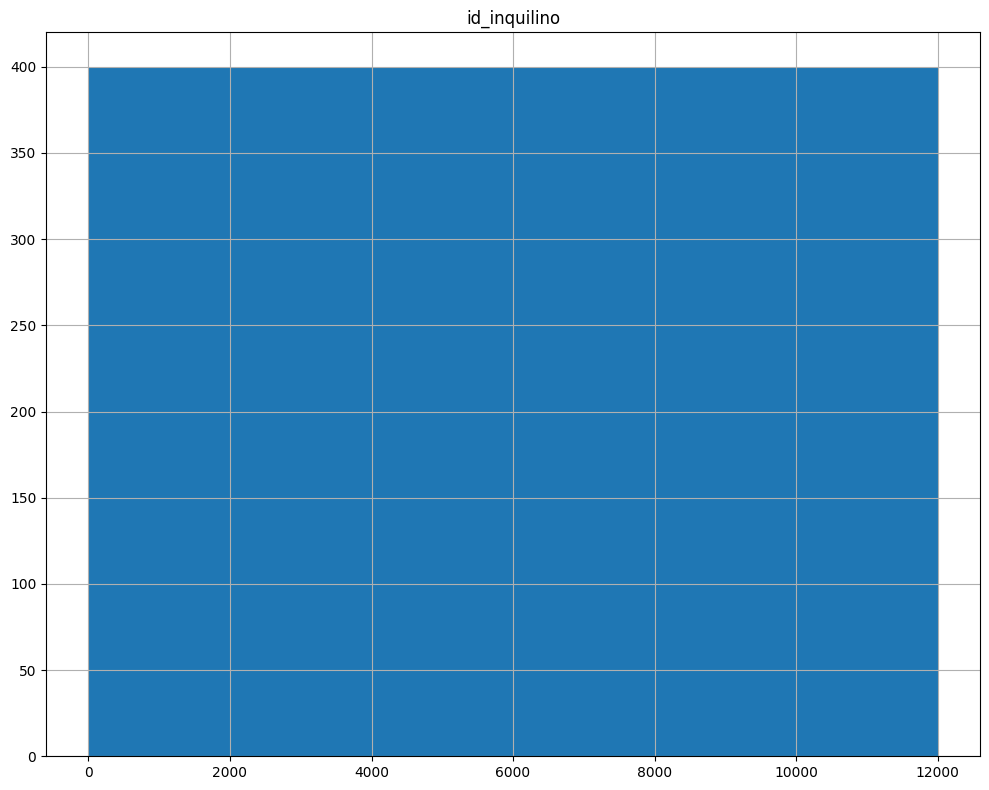

In [ ]:
#RETO 1.5 — Histograma global (columnas numéricas)
inquilinos.hist(bins=30, figsize=(10, 8))
plt.show()


In [ ]:
#RETO 1.6 — Nulos por columna
inquilinos.isnull().sum()


,0
id_inquilino,0
horario,0
ritmo,0
animacion,0
nivel_educativo,0
cine,0
leer,0
deporte,0
mascotas,0
comida,0


In [ ]:
#RETO 1.9 — Conteos por columna (excepto id)
for col in inquilinos.drop('id_inquilino', axis=1, errors='ignore').columns:
    print("--- {} ---".format(col))
    print(inquilinos[col].value_counts())
    print()


--- horario ---
horario
noche      6295
ma√±ana    5705
Name: count, dtype: int64

--- ritmo ---
ritmo
madrugador    6311
nocturno      5689
Name: count, dtype: int64

--- animacion ---
animacion
si    6232
no    5768
Name: count, dtype: int64

--- nivel_educativo ---
nivel_educativo
universitaria    5814
secundaria       3395
primaria         2791
Name: count, dtype: int64

--- cine ---
cine
no    6017
si    5983
Name: count, dtype: int64

--- leer  ---
leer 
no    6420
si    5580
Name: count, dtype: int64

--- deporte  ---
deporte 
si    6426
no    5574
Name: count, dtype: int64

--- mascotas ---
mascotas
con mascotas    6361
sin mascotas    5639
Name: count, dtype: int64

--- comida ---
comida
pedir comida    6674
cocinar         5326
Name: count, dtype: int64

--- dieta ---
dieta
no    6031
si    5969
Name: count, dtype: int64

--- fumador ---
fumador
no    6157
si    5843
Name: count, dtype: int64

--- visitas ---
visitas
si    6419
no    5581
Name: count, dtype: int64

--- orden 

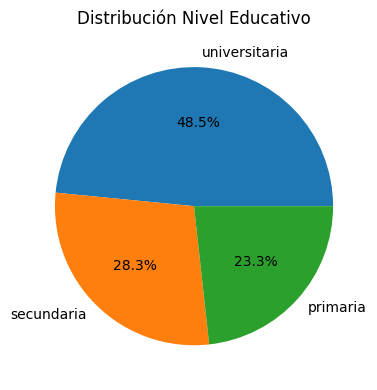

In [ ]:
#RETO 1.10 — Pie de nivel educativo
plt.figure(figsize=(6, 4))
nivel_counts = inquilinos['nivel_educativo'].value_counts()
plt.pie(nivel_counts.values, labels=nivel_counts.index.tolist(), autopct='%1.1f%%')
plt.title('Distribución Nivel Educativo')
plt.show()


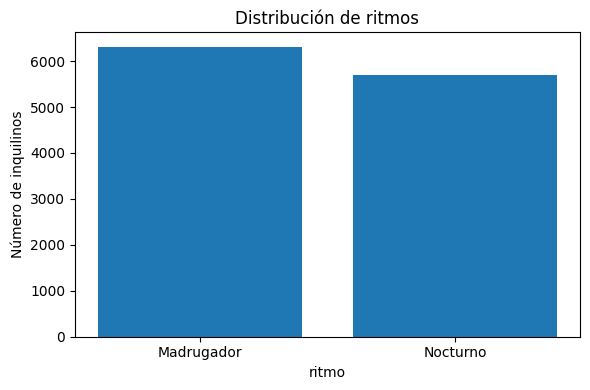

In [ ]:
#RETO 1.11 — Barras de ritmo
plt.figure(figsize=(6, 4))
rcount = inquilinos['ritmo'].value_counts()
plt.bar(rcount.index, rcount.values)
plt.title('Distribución de ritmos')
plt.xlabel('ritmo')
plt.ylabel('Número de inquilinos')
plt.xticks(ticks=range(len(rcount.index)), labels=['Madrugador','Nocturno'])
plt.show()


In [ ]:
#RETO 2.0 — Copia y mapeos binarios (preprocesamiento)
df = inquilinos.copy()
for c in ['id_inquilino', 'musica_tipo', 'nivel_educativo', 'instrumento']:
    if c in df.columns:
        df.drop(c, axis=1, inplace=True)
binarias = {
    'animacion': {'si': 1, 'no': 0},
    'cine': {'si': 1, 'no': 0},
    'leer': {'si': 1, 'no': 0},
    'deporte': {'si': 1, 'no': 0},
    'dieta': {'si': 1, 'no': 0},
    'fumador': {'si': 1, 'no': 0},
    'visitas': {'si': 1, 'no': 0},
    'musica_alta': {'si': 1, 'no': 0},
    'mascotas': {'con mascotas': 1, 'sin mascotas': 0},
    'comida': {'pedir comida': 0, 'cocinar': 1},
    'orden': {'relajada': 0, 'ordenada': 1},
    'plan_perfecto': {'casa': 0, 'salir': 1},
    'ritmo': {'madrugador': 1, 'nocturno': 0},
    'horario': {'mañana': 1, 'noche': 0}
}
for col, mapping in binarias.items():
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower().map(mapping)


In [ ]:
#RETO 2.1 — Split + modelos
TARGET = 'ritmo'
assert TARGET in df.columns, 'No existe la columna {}'.format(TARGET)
X = df.drop(TARGET, axis=1).select_dtypes(include=[np.number])
y = df[TARGET]

X.isna().sum()[lambda s: s>0]


from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='most_frequent')
X = pd.DataFrame(imp.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
modelos = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=7)
}
metricas = {}
for name, model in modelos.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    metricas[name] = {'accuracy': acc, 'precision': pre, 'recall': rec, 'f1': f1}
metricas


{'DecisionTree': {'accuracy': 0.75,
  'precision': 0.7530008983226676,
  'recall': 0.75,
  'f1': 0.7500902840475032},
 'RandomForest': {'accuracy': 0.7525,
  'precision': 0.7535867983021468,
  'recall': 0.7525,
  'f1': 0.7526625601640284},
 'KNN': {'accuracy': 0.725,
  'precision': 0.7306844638350322,
  'recall': 0.725,
  'f1': 0.7247616242887625}}

Mejor modelo: RandomForest 

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       569
           1       0.78      0.74      0.76       631

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



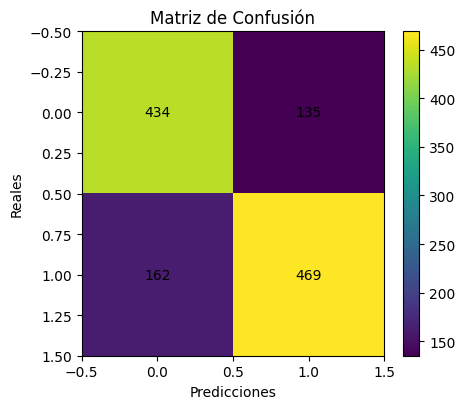

In [ ]:
#RETO 2.2 — Mejor modelo + Reporte + Matriz de Confusión
best_name = max(metricas, key=lambda k: metricas[k]['accuracy'])
best_model = modelos[best_name]
y_pred = best_model.predict(X_test)
print('Mejor modelo:', best_name, '\n')
print(classification_report(y_test, y_pred, zero_division=0))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.8, 4.2))
plt.imshow(cm, aspect='auto')
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Reales')
plt.colorbar()
for (i, j), val in np.ndenumerate(cm):
    plt.text(j, i, str(val), ha='center', va='center')
plt.tight_layout()
plt.savefig('cm_actual.png', dpi=120, bbox_inches='tight')
plt.show()


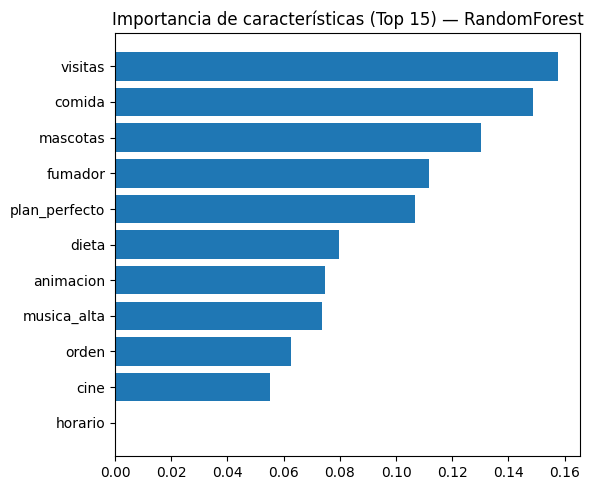

In [ ]:
#RETO 2.3 — Importancia de variables (si aplica)
try:
    importancias = best_model.feature_importances_
    idx = np.argsort(importancias)[::-1][:15]
    plt.figure(figsize=(6, 5))
    plt.barh(range(len(idx)), importancias[idx])
    plt.yticks(range(len(idx)), X.columns[idx])
    plt.gca().invert_yaxis()
    plt.title('Importancia de características (Top 15) — {}'.format(best_name))
    plt.tight_layout()
    plt.savefig('fi_actual.png', dpi=120, bbox_inches='tight')
    plt.show()
except Exception as e:
    print('El modelo seleccionado no soporta importancias:', e)
    importancias = None


In [ ]:
#RETO 3.0 — Informe Markdown dentro del mismo notebook
acc = metricas[best_name]['accuracy']
pre = metricas[best_name]['precision']
rec = metricas[best_name]['recall']
f1  = metricas[best_name]['f1']

tabla = (
    "| Métrica | Valor |\n|---|---:|\n"
    + "| Accuracy | {:.3f} |\n".format(acc)
    + "| Precision (weighted) | {:.3f} |\n".format(pre)
    + "| Recall (weighted) | {:.3f} |\n".format(rec)
    + "| F1 (weighted) | {:.3f} |".format(f1)
)

imp_md = ""
if 'importancias' in locals() and importancias is not None:
    pares = [(X.columns[i], float(importancias[i])) for i in idx]
    filas = "\n".join(["| {} | {:.4f} |".format(n, v) for n, v in pares])
    imp_md = (
        "\n\n**Importancia de características (Top 15)**\n\n"
        + "| Variable | Importancia |\n|---|---:|\n" + filas
    )

md = (
    "# Informe — Dataset de Inquilinos\n\n"
    + "**Archivo:** `{}`  \\n".format(inquilinos)
    + "**Objetivo:** `{}`  \\n".format(TARGET)
    + "**Mejor modelo:** `{}`\n\n".format(best_name)
    + "## 1) EDA breve\n"
    + "- Columnas categóricas principales exploradas (conteos y distribuciones).\n"
    + "- Gráficas: Nivel educativo (pie), Ritmo (barras).\n"
    + "- Revisar nulos y valores únicos en las celdas previas.\n\n"
    + "## 2) Preprocesamiento\n"
    + "- Mapeos binarios de texto → 0/1 (si/no, con/sin, madrugador/nocturno, etc.).\n"
    + "- Columnas textuales no usadas removidas: `id_inquilino`, `musica_tipo`, `nivel_educativo`, `instrumento`.\n\n"
    + "## 3) Modelado\n"
    + "- Train/Test split (estratificado, 10% test).\n"
    + "- Modelos comparados: DecisionTree, RandomForest, KNN.\n"
    + "- Selección por accuracy en test.\n\n"
    + "## 4) Métricas (Test)\n"
    + tabla + "\n\n"
    + "### Matriz de confusión\n"
    + "![cm](cm_actual.png)\n\n"
    + imp_md + "\n\n"
    + "## 5) Conclusiones\n"
    + "- El modelo `{}` obtiene accuracy ~ {:.2%} en este split.\n".format(best_name, acc)
    + "- Recomendado: ajustar hiperparámetros, revisar desbalance y evaluar ROC/PR.\n"
    + "- Probar otros objetivos (`fumador`, etc.) repitiendo las celdas de modelado.\n"
)

display(Markdown(md))
with open("Informe_Colab.md", "w", encoding="utf-8") as f:
    f.write(md)


# Informe — Dataset de Inquilinos

**Archivo:** `       id_inquilino  horario       ritmo animacion nivel_educativo cine leer   \
0                 1    noche    nocturno        si      secundaria   si    no   
1                 2    noche    nocturno        no      secundaria   no    no   
2                 3    noche  madrugador        no   universitaria   no    no   
3                 4    noche    nocturno        no   universitaria   si    si   
4                 5  ma√±ana    nocturno        si   universitaria   no    no   
...             ...      ...         ...       ...             ...  ...   ...   
11995         11996    noche    nocturno        no      secundaria   no    si   
11996         11997    noche    nocturno        no        primaria   si    si   
11997         11998    noche  madrugador        no      secundaria   si    si   
11998         11999    noche  madrugador        si   universitaria   no    no   
11999         12000    noche    nocturno        no        primaria   no    si   

      deporte       mascotas        comida dieta fumador visitas     orden  \
0           no  con mascotas  pedir comida    si      si      si  relajada   
1           no  con mascotas  pedir comida    no      si      si  relajada   
2           si  con mascotas  pedir comida    no      si      no  ordenada   
3           no  con mascotas  pedir comida    no      no      si  relajada   
4           no  sin mascotas       cocinar    no      no      no  relajada   
...        ...           ...           ...   ...     ...     ...       ...   
11995       si  sin mascotas  pedir comida    si      si      si  ordenada   
11996       no  con mascotas  pedir comida    si      si      si  relajada   
11997       no  con mascotas  pedir comida    no      si      no  relajada   
11998       si  sin mascotas       cocinar    no      no      no  ordenada   
11999       si  con mascotas  pedir comida    si      si      no  relajada   

      musica_tipo musica_alta plan_perfecto instrumento  
0       reggaeton          no          casa          si  
1       reggaeton          si          casa          si  
2             pop          no          casa          no  
3            rock          si          casa          si  
4             pop          no          casa          no  
...           ...         ...           ...         ...  
11995   reggaeton          si         salir          si  
11996   reggaeton          si          casa          si  
11997   reggaeton          si         salir          si  
11998         pop          no          casa          no  
11999        rock          si         salir          si  

[12000 rows x 18 columns]`  \n**Objetivo:** `ritmo`  \n**Mejor modelo:** `RandomForest`

## 1) EDA breve
- Columnas categóricas principales exploradas (conteos y distribuciones).
- Gráficas: Nivel educativo (pie), Ritmo (barras).
- Revisar nulos y valores únicos en las celdas previas.

## 2) Preprocesamiento
- Mapeos binarios de texto → 0/1 (si/no, con/sin, madrugador/nocturno, etc.).
- Columnas textuales no usadas removidas: `id_inquilino`, `musica_tipo`, `nivel_educativo`, `instrumento`.

## 3) Modelado
- Train/Test split (estratificado, 10% test).
- Modelos comparados: DecisionTree, RandomForest, KNN.
- Selección por accuracy en test.

## 4) Métricas (Test)
| Métrica | Valor |
|---|---:|
| Accuracy | 0.752 |
| Precision (weighted) | 0.754 |
| Recall (weighted) | 0.752 |
| F1 (weighted) | 0.753 |

### Matriz de confusión
![cm](cm_actual.png)



**Importancia de características (Top 15)**

| Variable | Importancia |
|---|---:|
| visitas | 0.1575 |
| comida | 0.1487 |
| mascotas | 0.1302 |
| fumador | 0.1116 |
| plan_perfecto | 0.1067 |
| dieta | 0.0796 |
| animacion | 0.0748 |
| musica_alta | 0.0735 |
| orden | 0.0625 |
| cine | 0.0550 |
| horario | 0.0000 |

## 5) Conclusiones
- El modelo `RandomForest` obtiene accuracy ~ 75.25% en este split.
- Recomendado: ajustar hiperparámetros, revisar desbalance y evaluar ROC/PR.
- Probar otros objetivos (`fumador`, etc.) repitiendo las celdas de modelado.
